## Exercise 1

[OpenStreetMap](https://www.openstreetmap.org/)'s Nominatim API can be used, among other things, to find the precise geographic coordinates of a specific location. The base URL of this API is <https://nominatim.openstreetmap.org/search>.

Following the `q` parameter, you need to supply a string describing the locations whose latitude and longitude you want to find. As values for the `format` parameter, you can use `xml` for XML-formatted data or `json` for JSON-formatted data. 

When you request information from the OpenStreetMap API, you also need specify a user agent, in the `headers` paramerer of the `get` method. It typically includes information about the software, the operating system, and sometimes additional details such as the device type or version numbers. The user agent can be seen as a fingerprint that identifies the client.

```python
headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10.15; rv:136.0) Gecko/20100101 Firefox/136.0'}
```

The API call via `requests` can then take place as follows:

```python
response = requests.get(url,headers=headers)
```

You can find a valid User Agent string by making use of the following websites. 

* https://www.whatismybrowser.com/detect/what-is-my-user-agent/
* https://dnschecker.org/user-agent-info.php


Using [OpenStreetMap](https://www.openstreetmap.org/)'s Nominatim API, try to find the longitude and the latitude of the addresses in the following list:

```
addresses = ['Grote Looiersstraat 17 Maastricht' , 'Witte Singel 27 Leiden' ,
'Singel 425 Amsterdam' , 'Drift 27 Utrecht' , 'Broerstraat 4 Groningen']
```

The JSON data received via the OpenStreetMap API can be converted to regular Python lists and dictionaries using the `json()` method: 

```json_data = response.json()```

If the result is saved as variable named `json_data`, you should be able to access the latitude and the longitude as follows:

```
latitude = json_data[0]['lat']
longitude = json_data[0]['lon']
```

The `[0]` is used to get the results for the first result.

Print each address and its latitude and longitude coordinates.



In [ ]:
import requests
import urllib.parse

addresses = ['Grote Looiersstraat 17 Maastricht' , 
             'Witte Singel 27 Leiden','Singel 425 Amsterdam' , 
             'Drift 27 Utrecht' , 'Broerstraat 4 Groningen']

headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10.15; rv:136.0) Gecko/20100101 Firefox/136.0'}


for a in addresses:
    
    print(a)
    
    # URL encode the address
    a_encoded = urllib.parse.quote(a)
    
    # Create the API call
    # Base url is 'https://nominatim.openstreetmap.org/search'
    # Use the parameters 'q' and 'format' 
    
    api_call = ''
    
    # Get the JSON data and process the data using json()
    response = requests.get(api_call,headers=headers)
    print(response.status_code)
    if response.status_code == 200:
        json_data = response.json()
    
        # Find the latitude and the longitude of the first result
        latitude = json_data[0]['lat']
        longitude = json_data[0]['lon']
        print(latitude,longitude)
    

## Exercise 2

The API made available on [Nobelprize.org](https://www.nobelprize.org/about/developer-zone-2/) provides up-to-date information about Nobel Prizes and laureates. The data is updated each time new laureates are announed. 

The base URL of the API is as follows: 

[https://api.nobelprize.org/2.1/laureates](https://api.nobelprize.org/2.1/laureates)

You can work with the `limit` parameter, which specifies the number of results. The `offset` parameter specific the index of the first item in the result set. The default value for the  `limit` parameter is 25. 

The code below print the full JSON data for the laureates contained in the result set. Can you write code that displays each the `knownName` in English and birth date for each person?

The 'known name' can be found via the key named `knownName`. This key is linked, in turn, to a nested JSON object. The English known name can be found via the `en` key. 

The birth date can similarly be found as follows:

```laureate['birth']['date']```

Once you have made these changes, can you also change the number of results? Can you display data about 100 Nobel laureates, for example? 

In [ ]:
import requests

headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10.15; rv:136.0) Gecko/20100101 Firefox/136.0'}

url = 'https://api.nobelprize.org/2.1/laureates?limit=25&offset=0'

response = requests.get(url,headers=headers)

if response:
    json_data = response.json()
    for laureate in json_data['laureates']:
        print(laureate)

## Exercise 3

Run the cell below to download the updated data set about the Nobel laureates. 

Next, try to sort the dataset by `laureate_id`. 


Can you also write code to sort the data set on the basis of the data on which the Nobel prizes were awarded? This value can be found in the column named `prize_date`. Order the data set in a reverse chronological order. 

In [2]:
import requests
import pandas as pd

out = open('nobel.csv','w',encoding='utf-8')

response = requests.get('https://raw.githubusercontent.com/peterverhaar/python_tutorial/refs/heads/main/nobel.csv')
if response:
    out.write(response.text)
    print('The CSV file has been downloaded!')

out.close()

nobel = pd.read_csv('nobel.csv')

The CSV file has been downloaded!


,laureate_id,full_name,given_name,family_name,gender,birth_date,birth_country,birth_city,prize_date,category,prizeAmount,motivation
0,745,A. Michael Spence,A. Michael,Spence,male,1943-00-00,USA,"Montclair, NJ",2001-10-10,Economic Sciences,10000000,for their analyses of markets with asymmetric ...
1,102,Aage N. Bohr,Aage N.,Bohr,male,1922-06-19,Denmark,Copenhagen,1975-10-17,Physics,630000,for the discovery of the connection between co...
2,779,Aaron Ciechanover,Aaron,Ciechanover,male,1947-10-01,British Protectorate of Palestine,Haifa,2004-10-06,Chemistry,10000000,for the discovery of ubiquitin-mediated protei...
3,259,Aaron Klug,Aaron,Klug,male,1926-08-11,Lithuania,Zelvas,1982-10-18,Chemistry,1150000,for his development of crystallographic electr...
4,1004,Abdulrazak Gurnah,Abdulrazak,Gurnah,male,1948-00-00,NaN,NaN,2021-10-07,Literature,10000000,for his uncompromising and compassionate penet...


## Exercise 4

The code in the cell below groups the nobel data set by categories and counts the number of laureates. 

Can you create a barplot to clarify the number of Nobel Laureats per category? 

The values that need to shown are stored in the lists named `x_axis` and `y_axis`. The `data` parameter should not be used. 

Customise the barplot using the following specifications: 

* color: '#910c26'
* Size of the plot: 10 x 7
* Rotate X-tick labels by 80 degrees
* Title: 'Nobel Laureates data set'
* X-axis label: 'Categories'
* Y-axis label: 'Number of laureates'
* Font size of the axes labels: 17

In [31]:
nobel.groupby('category')['laureate_id'].count()

category
Chemistry                 200
Economic Sciences          99
Literature                122
Peace                     143
Physics                   230
Physiology or Medicine    232
Name: laureate_id, dtype: int64

In [25]:
def sorted_by_value( dict , ascending = True ):
    if ascending: 
        return {k: v for k, v in sorted(dict.items(), key=lambda item: item[1])}
    else:
        return {k: v for k, v in reversed( sorted(dict.items(), key=lambda item: item[1]))}

laureates_per_category = nobel.groupby('category')['laureate_id'].count().to_dict()
laureates_per_category = sorted_by_value(laureates_per_category,ascending=False)

x_axis = list(laureates_per_category.keys())
y_axis = list(laureates_per_category.values())

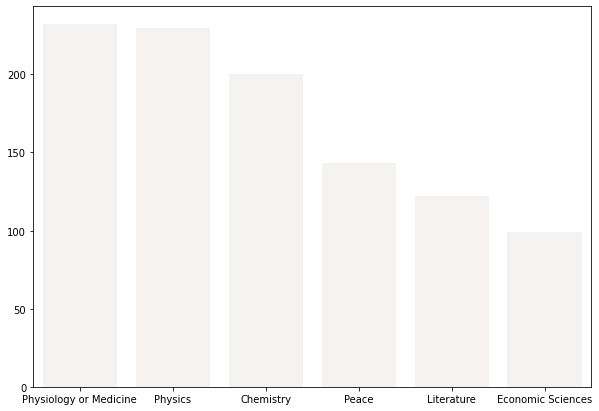

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure( figsize=( 10 , 7 ) )

graph = sns.barplot( x=x_axis, y= y_axis, color = '#f5f3f2'  )

graph.set_title('' , size = 3) 
graph.set_xlabel('' , size = 3) 
graph.set_ylabel('' , size = 3 )

plt.xticks(rotation=0)

plt.show()

## Exercise 5

Create a lineplot in Seaborn to visualize the number of Nobel laureates per year.

Customise the plot using the followinh specifications:

* color of the line: '#94321c’
* linewidth: 3 
* Size of the plot: 10 x 3
* Graph title: 'Number of Nobel laureates per year'
* Plot style: 'whitegrid'

In [42]:
nobel['year'] = pd.to_datetime(nobel['prize_date']).dt.year
nobel = nobel.sort_values(by='year')

laureates_per_year = nobel.groupby('year')['laureate_id'].count()
laureates_per_year = laureates_per_year.to_dict()

x_axis = laureates_per_year.keys()
y_axis = laureates_per_year.values()

## Exercise 7

Download the OECDE *Better Life Index* dataset using the code in the cell below. 

Next, create a scatter plot with the following characteristics.

* Values on x_axis: 'air_pollution'
* Values on y_axis: 'water_quality'
* Point size: 'personal_earnings'
* Minimum point size: 100
* Maximum point size: 1000
* Point colour: 'educational_attainment'
* Colour palette: 'Blues'
* Size of the plot: 10x10

Save the plot as "scatterplot.png" 

In [59]:
import requests
import pandas as pd
from os.path import basename


url = 'https://raw.githubusercontent.com/cdsleiden/python-tutorial/refs/heads/main/notebooks/Data/bli.csv'
file_name = basename(url)


out = open(file_name,'w',encoding='utf-8')

response = requests.get(url)
if response:
    out.write(response.text)
    print('The CSV file has been downloaded!')

out.close()

bli = pd.read_csv(file_name)

x_axis = 'air_pollution'
y_axis = 'water_quality'

bli = bli.dropna(subset = [x_axis, y_axis])

The CSV file has been downloaded!


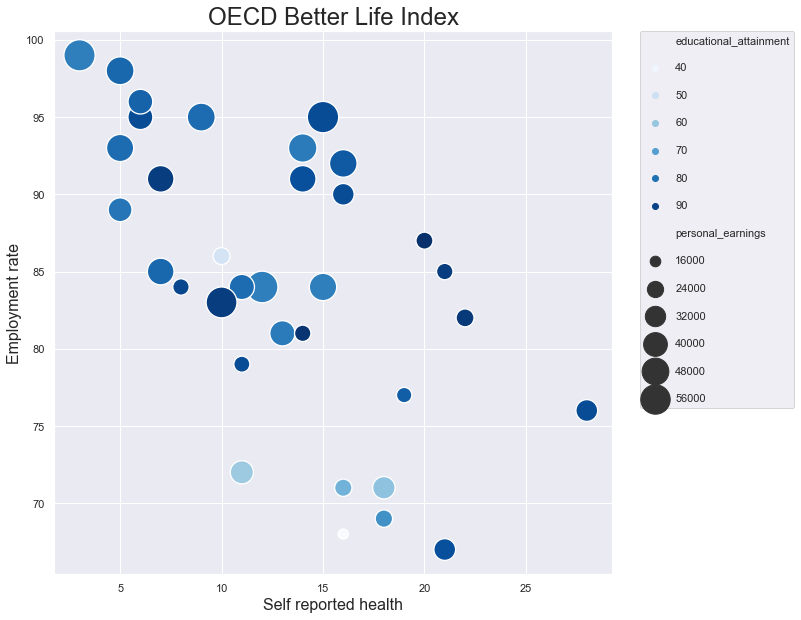

Index(['country', 'continent', 'labour_market_insecurity',
       'stakeholder_engagement_for_developing_regulations',
       'dwellings_without_basic_facilities', 'housing_expenditure',
       'feeling_safe_walking_alone_at_night', 'rooms_per_person',
       'household_net_adjusted_disposable_income', 'household_net_wealth',
       'employment_rate', 'long-term_unemployment_rate', 'personal_earnings',
       'quality_of_support_network', 'educational_attainment',
       'student_skills', 'years_in_education', 'air_pollution',
       'water_quality', 'voter_turnout', 'life_expectancy',
       'self-reported_health', 'life_satisfaction', 'homicide_rate',
       'employees_working_very_long_hours',
       'time_devoted_to_leisure_and_personal_care'],
      dtype='object')